# Superstore: regional profitability and dispatch performance

This re-executable analysis separates transaction lines, distinct orders and order-to-ship time. Ship Date records dispatch, not customer delivery. A >5-day flag is an analytical threshold, not a verified contractual SLA.

In [1]:
from pathlib import Path
import hashlib, json
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
OUT = ROOT / 'outputs'; OUT.mkdir(exist_ok=True)
path = ROOT / 'data' / 'Sample - Superstore.csv'
df = pd.read_csv(path, encoding='latin1')
for col in ['Order Date','Ship Date']: df[col] = pd.to_datetime(df[col], format='%m/%d/%Y')
df['Days to Ship'] = (df['Ship Date']-df['Order Date']).dt.days
assert df['Row ID'].is_unique and df['Days to Ship'].ge(0).all()
# Check that reducing to one row per order is valid for operational attributes.
attrs = ['Region','Ship Mode','Order Date','Ship Date']
assert df.groupby('Order ID')[attrs].nunique().le(1).all().all()
orders = df.drop_duplicates('Order ID').copy()
print(f'{len(df):,} lines; {len(orders):,} distinct orders')
print('SHA-256:', hashlib.sha256(path.read_bytes()).hexdigest())

9,994 lines; 5,009 distinct orders
SHA-256: 58fb59c63089e564d835e4aabe19d371757de1137a5bf1888243ae386c4b7a97


             Sales     Profit  Orders  Margin (%)
Region                                           
Central  501239.89   39706.36    1175        7.92
East     678781.24   91522.78    1401       13.48
South    391721.90   46749.43     822       11.93
West     725457.82  108418.45    1611       14.94


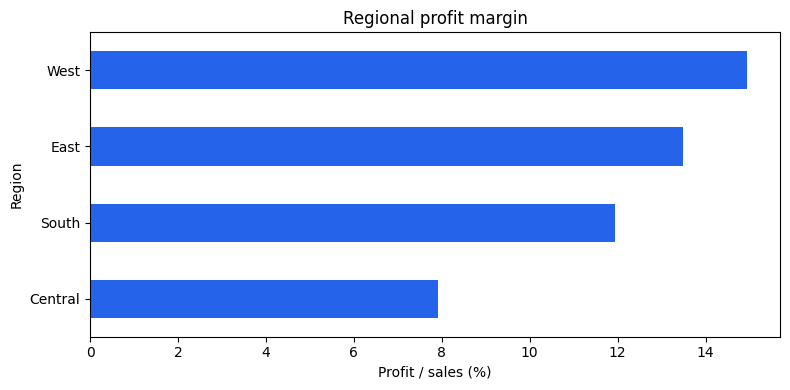

In [2]:
regional = df.groupby('Region').agg(Sales=('Sales','sum'), Profit=('Profit','sum'), Orders=('Order ID','nunique'))
regional['Margin (%)'] = 100*regional['Profit']/regional['Sales']
regional.to_csv(OUT/'regional_metrics.csv')
print(regional.round(2).to_string())
ax=regional['Margin (%)'].sort_values().plot.barh(color='#2563eb',figsize=(8,4))
ax.set(xlabel='Profit / sales (%)', title='Regional profit margin')
plt.tight_layout(); plt.savefig(OUT/'regional_margin.png',dpi=160);plt.show()

In [3]:
standard = orders.loc[orders['Ship Mode'].eq('Standard Class')].copy()
standard['Over 5 days'] = standard['Days to Ship'].gt(5)
dispatch = standard.groupby('Region').agg(Orders=('Order ID','nunique'), Over_5_days=('Over 5 days','sum'), Mean_days=('Days to Ship','mean'))
dispatch['Over_5_days_rate_pct'] = 100*dispatch['Over_5_days']/dispatch['Orders']
dispatch.to_csv(OUT/'standard_dispatch_metrics.csv')
print(dispatch.round(2).to_string())

         Orders  Over_5_days  Mean_days  Over_5_days_rate_pct
Region                                                       
Central     715          221       4.99                 30.91
East        828          249       4.98                 30.07
South       495          144       5.00                 29.09
West        956          290       5.03                 30.33


In [4]:
product = df.groupby(['Region','Category','Sub-Category']).agg(Sales=('Sales','sum'), Profit=('Profit','sum'), Mean_line_discount=('Discount','mean'))
product['Margin_pct'] = 100*product['Profit']/product['Sales']
product.to_csv(OUT/'product_metrics.csv')
print(product.loc['Central'].sort_values('Profit').head(6).round(2).to_string())
summary = {'source_sha256':hashlib.sha256(path.read_bytes()).hexdigest(), 'lines':len(df), 'orders':len(orders), 'sales':float(df.Sales.sum()), 'profit':float(df.Profit.sum()), 'margin_pct':float(100*df.Profit.sum()/df.Sales.sum()), 'central_margin_pct':float(regional.loc['Central','Margin (%)']), 'west_margin_pct':float(regional.loc['West','Margin (%)'])}
(OUT/'validation.json').write_text(json.dumps(summary,indent=2))

                                 Sales   Profit  Mean_line_discount  Margin_pct
Category        Sub-Category                                                   
Furniture       Furnishings   15254.37 -3906.22                0.40      -25.61
                Tables        39154.97 -3559.65                0.26       -9.09
Office Supplies Appliances    23582.03 -2638.62                0.45      -11.19
Furniture       Bookcases     24157.18 -1997.90                0.23       -8.27
Technology      Machines      26797.38 -1486.07                0.33       -5.55
Office Supplies Binders       56923.28 -1043.64                0.51       -1.83


## Interpretation

Central has the lowest regional margin. Inspect category/subcategory losses and discounts as commercial hypotheses. Similar dispatch times do not rule out logistics costs or delivery problems: neither actual delivery dates nor a cost breakdown is present. Discount caps require an experiment or defensible causal design; this dataset alone cannot establish their incremental profit impact.

The archived Power BI/report files predate this terminology correction. This notebook and its exported CSVs are the current reference for dispatch metrics.